In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Download 1 year of data for DBS, OCBC, SGX
tickers = ['D05.SI', 'O39.SI', 'S68.SI']
data = yf.download(tickers, period='1y', auto_adjust=True)['Close']

# Show the data
print(data.head(10))
print()

[*********************100%***********************]  3 of 3 completed

1 Failed download:
['D05.SI']: OperationalError('database is locked')


Ticker      D05.SI     O39.SI     S68.SI
Date                                    
2025-07-31     NaN  16.042532  15.630064
2025-08-01     NaN  15.966456  15.542146
2025-08-04     NaN  16.071060  15.678908
2025-08-05     NaN  16.147135  15.913363
2025-08-06     NaN  16.204193  15.903591
2025-08-07     NaN  16.251740  15.962204
2025-08-08     NaN  16.358917  15.649603
2025-08-11     NaN  16.446604  15.581221
2025-08-12     NaN  16.319942  15.258850
2025-08-13     NaN  16.378401  15.571451



In [2]:
start_price = data.iloc[0]
end_price = data.iloc[-1]
returns = (end_price - start_price) / start_price * 100

print("Annual Returns (%) — Jul 2025 to Jul 2026")
print(returns.round(2))
print()

Annual Returns (%) — Jul 2025 to Jul 2026
Ticker
D05.SI      NaN
O39.SI    81.58
S68.SI    56.49
dtype: float64



In [3]:
# 20-day and 50-day moving averages for DBS
dbs = data['D05.SI']
dbs_20ma = dbs.rolling(window=20).mean()
dbs_50ma = dbs.rolling(window=50).mean()

print("DBS — Last 5 days of Moving Averages")
print("20-day MA:")
print(dbs_20ma.tail())
print()
print("50-day MA:")
print(dbs_50ma.tail())

DBS — Last 5 days of Moving Averages
20-day MA:
Date
2026-07-27   NaN
2026-07-28   NaN
2026-07-29   NaN
2026-07-30   NaN
2026-07-31   NaN
Name: D05.SI, dtype: float64

50-day MA:
Date
2026-07-27   NaN
2026-07-28   NaN
2026-07-29   NaN
2026-07-30   NaN
2026-07-31   NaN
Name: D05.SI, dtype: float64


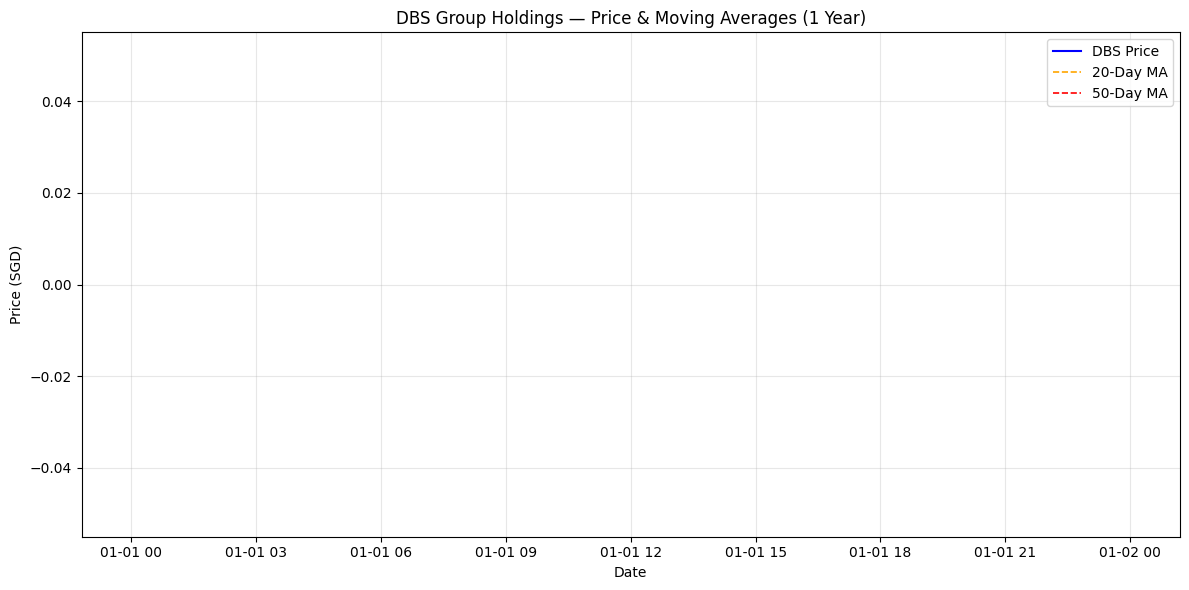

In [4]:
# Plot DBS price with moving averages
plt.figure(figsize=(12, 6))
plt.plot(dbs, label='DBS Price', linewidth=1.5, color='blue')
plt.plot(dbs_20ma, label='20-Day MA', linestyle='--', 
         linewidth=1.2, color='orange')
plt.plot(dbs_50ma, label='50-Day MA', linestyle='--', 
         linewidth=1.2, color='red')
plt.title('DBS Group Holdings — Price & Moving Averages (1 Year)')
plt.xlabel('Date')
plt.ylabel('Price (SGD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# Full portfolio summary
print("=" * 45)
print("SGX STOCK PORTFOLIO TRACKER — SUMMARY")
print("=" * 45)
print(f"\nPeriod: {data.index[0].date()} to {data.index[-1].date()}")
print("\nAnnual Returns:")
for ticker, ret in returns.items():
    print(f"  {ticker}: {ret:+.2f}%")

print("\nCurrent Prices (SGD):")
for ticker, price in data.iloc[-1].items():
    print(f"  {ticker}: S${price:.2f}")

print("\nDBS Moving Averages (latest):")
print(f"  20-day MA: S${dbs_20ma.iloc[-1]:.2f}")
print(f"  50-day MA: S${dbs_50ma.iloc[-1]:.2f}")
print(f"  Signal: ", end="")
if dbs_20ma.iloc[-1] > dbs_50ma.iloc[-1]:
    print("BULLISH — 20MA above 50MA")
else:
    print("BEARISH — 20MA below 50MA")
print("=" * 45)

SGX STOCK PORTFOLIO TRACKER — SUMMARY

Period: 2025-07-31 to 2026-07-31

Annual Returns:
  D05.SI: +nan%
  O39.SI: +81.58%
  S68.SI: +56.49%

Current Prices (SGD):
  D05.SI: S$nan
  O39.SI: S$29.13
  S68.SI: S$24.46

DBS Moving Averages (latest):
  20-day MA: S$nan
  50-day MA: S$nan
  Signal: BEARISH — 20MA below 50MA


In [6]:
import sqlite3

# Create a simple database from the stock data
conn = sqlite3.connect('sgx_stocks.db')

# Save the data into a SQL table
data.to_sql('stock_prices', conn, if_exists='replace')

# Query it with SQL
query = '''
SELECT 
    Date,
    "D05.SI" as DBS,
    "O39.SI" as OCBC,
    "S68.SI" as SGX
FROM stock_prices
ORDER BY Date DESC
LIMIT 10
'''

import pandas as pd
result = pd.read_sql_query(query, conn)
print("Latest 10 days of stock prices from SQL database:")
print(result)

conn.close()

Latest 10 days of stock prices from SQL database:
                  Date   DBS       OCBC        SGX
0  2026-07-31 00:00:00  None  29.129999  24.459999
1  2026-07-30 00:00:00  None  29.100000  24.120001
2  2026-07-29 00:00:00  None  29.780001  24.030001
3  2026-07-28 00:00:00  None  28.930000  24.030001
4  2026-07-27 00:00:00  None  29.290001  23.950001
5  2026-07-24 00:00:00  None  29.090000  23.650000
6  2026-07-23 00:00:00  None  28.900000  23.700001
7  2026-07-22 00:00:00  None  29.180000  23.540001
8  2026-07-21 00:00:00  None  28.639999  23.450001
9  2026-07-20 00:00:00  None  28.690001  23.629999
